# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [1]:
import os
from collections import defaultdict
from datetime import datetime

from enum import Enum
import numpy as np
import random

import qiskit
import qiskit_aer
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit.transpiler.passes import RemoveBarriers
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.providers.fake_provider import GenericBackendV2

from ewfs.noise_models import depolarizing_noise_model, bitflip_model
from ewfs.file_io import save_data
from ewfs.ghz_utils import GHZCircuitBuilder, plot_ghz_fez

In [2]:
# Settings for extended Wigner's friend scenario.
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3


# Observers for scenario are Alice and Bob.
class Observer(Enum):
    ALICE = 0
    BOB = 1


# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
# ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
# BETA = np.deg2rad(175)

# Optimized angles (refer to paper).
ANGLES = {PEEK: np.deg2rad(40), REVERSE_1: np.deg2rad(230), REVERSE_2: np.deg2rad(310)}
BETA = np.deg2rad(220)

In [3]:
# Experimental settings:
shots = 10_000
num_trials = 2
friend_sizes = range(1, 3)
strategy = "majority_vote"
save = True

# Set backend and noise model:
#backend_name = "aer_simulator"
#backend = qiskit_aer.Aer.get_backend(backend_name)

# ibm_fez has 156 qubits, and this is what the Q-CTRL script focuses on.
backend_name = "fake_provider"
backend = GenericBackendV2(num_qubits=156)

noise_model = None

# Create timestamped directory to save results:
DATA_PATH = os.path.join("..", "data")
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
new_dir_name = f"{strategy}_{backend_name}_{timestamp}"
new_dir_path = os.path.join(DATA_PATH, new_dir_name)

if not os.path.exists(new_dir_path):
    os.makedirs(new_dir_path)

In [9]:
def generate_ghz_circuit(num_qubits: int, num_ghz_qubits: int = 54):
    if num_ghz_qubits == 30:
        qubits_to_remove = [56]
        start_qubit=67
        flags_physical=[56]
    
    elif num_ghz_qubits == 54:
        qubits_to_remove = [56, 58, 77, 78, 37, 38, 59, 20, 40, 60, 80, 34, 16, 18, 96, 94, 91]
        start_qubit=57
        flags_physical=[56, 58, 77, 38, 37, 59,]
    
    elif num_ghz_qubits == 70:
        qubit_to_remove = [56, 58, 77, 78, 37, 38, 59, 20, 40, 60, 80, 34, 16, 18, 96, 97, 110]
        start_qubit=67
        flags_physical=[56, 58, 77, 78, 38, 37, 59, 113]
    
    elif num_ghz_qubits == 75:
        qubit_to_remove = [56, 58, 77, 78, 37, 38, 59, 20, 40, 60, 80, 34, 16, 18, 96, 97, 110, 98, 39, 32, 16, 98]
        start_qubit=67
        flags_physical=[56, 58, 77, 78, 38, 37, 59, 113]
    
    elif num_ghz_qubits == 80:
        qubit_to_remove = [56, 58, 77, 78, 37, 38, 59, 20, 40, 60, 80, 34, 16, 18, 96, 97, 110, 98, 39, 32, 16, 98, 18]
        start_qubit=57
        flags_physical=[56, 58, 77, 78, 38, 37, 59, 16, 98, 18]
    
    ghz_builder = GHZCircuitBuilder(
        backend=backend,
        start_qubit=start_qubit,
        num_ghz_qubits=num_qubits,
        qubits_to_remove=qubits_to_remove,
        flags_physical=flags_physical,
        )
    build_result = ghz_builder.build()
    
    layout_without_flags = build_result['layout_without_flags']
    layout_with_flags = build_result['layout_with_flags']
    circuit_without_flags = build_result['circuit_without_flags']
    circuit_with_flags = build_result['circuit_with_flags']
    return circuit_with_flags

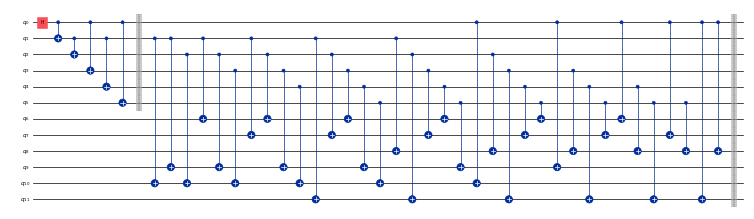

In [10]:
ghz_circuit = generate_ghz_circuit(num_qubits=6)
ghz_circuit.draw(output='mpl', idle_wires=False, style='iqp', fold=-1, scale=0.25)

In [15]:
def decode_results(results: dict, charlie_size: int, debbie_size: int = 1) -> dict[str, float]:
    """Take majority vote of measurement bit-strings."""
    decoded_results = {}

    # For each setting, there is a dictionary of measurement results.
    for setting in results:
        if setting == (PEEK, REVERSE_1) or setting == (PEEK, REVERSE_2):
            # Debbie's size is 1 because no PEEK setting
            debbie_size = 1

            setting_results = {}
            # Decode the keys for each measurement result of the setting.
            for k, v in results[setting].items():
                alice_friend, bob_friend = k[:charlie_size], k[-debbie_size:]

                alice_zero_count, bob_zero_count = alice_friend.count("0"), bob_friend.count("0")

                alice_decoding = "0" if alice_zero_count >= charlie_size // 2 + 1 else "1"
                bob_decoding = "0" if bob_zero_count >= 1 else "1"

                if alice_decoding + bob_decoding in setting_results.keys():
                    setting_results[alice_decoding + bob_decoding] += v
                else:
                    setting_results[alice_decoding + bob_decoding] = v
            decoded_results[setting] = setting_results
        else:
            decoded_results[setting] = results[setting]

    return decoded_results


def double_expect(settings: tuple[int, int], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return probs.get("00", 0) - probs.get("01", 0) - probs.get("10", 0) + probs.get("11", 0)


def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)


def cnot_ladder(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int, reverse: bool, internal_copy: bool):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    if internal_copy:
        if reverse:
            for i in range(friend_size-1):
                qc.cx(friend_qubit + friend_size-2-i, friend_qubit+friend_size-1-i)
            qc.cx(observer, friend_qubit)
        else:
            qc.cx(observer, friend_qubit)
            for i in range(friend_size-1):
                qc.cx(friend_qubit+i, friend_qubit + i + 1)
    else:
        if reverse:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit+friend_size-1-i)
        else:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit + i)


def cnot_ladder_random(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int):
    """CNOT ladder circuit (GHZ without Hadamard) for random strategy."""
    for i in range(friend_size):
        qc.cx(observer, friend_qubit + i)



def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)


def apply_setting(qc: QuantumCircuit,
                  strategy: str,
                  observer: int,
                  setting: int,
                  angle: float,
                  observer_creg: list[int] | int,
                  friend_qubits: list[int],
                  friend_size: int):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""
    if setting is PEEK:
        if strategy == "majority_vote":
            # Ask friend for the outcome.
            qc.measure(friend_qubits, observer_creg)
        elif strategy == "random":
            random_offset = random.randint(0, friend_size - 1)
            qc.measure(friend_qubits[0] + random_offset, observer)

    elif setting in [REVERSE_1, REVERSE_2]:
        qc.barrier(observer, friend_qubits)
        if strategy == "majority_vote":
            # TODO: GHZ circuit stuff.
            cnot_ladder(qc, observer, friend_qubits[0], friend_size, reverse=True, internal_copy=True)            
        elif strategy == "random":
            cnot_ladder_random(qc, observer, friend_qubits[0], friend_size)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)

        if observer is BOB:
            qc.h(BOB)
            qc.rz((BETA - ANGLES[1]), BOB)
        ewfs_rotation(qc, observer, angle)

        if strategy == "majority_vote":
            qc.measure(observer, observer_creg)
        elif strategy == "random":
            qc.measure(observer, observer)


def ewfs(alice_setting: int,
         bob_setting: int,
         strategy: str,
         angles: list[float],
         beta: float,
         charlie_size: int,
         debbie_size: int = 1) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""
    # Define quantum registers
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    meas_size = 2

    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name) 
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice's qubit", "Bob's qubit", "Charlie", "Debbie"])
    ]

    if strategy == "majority_vote":
        if (alice_setting == PEEK and bob_setting != PEEK):
            measurement = ClassicalRegister(charlie_size + 1, name="measurement")
            alice_creg = list(range(charlie_size))
            bob_creg = charlie_size
        else:
            measurement = ClassicalRegister(meas_size, name="measurement")
            alice_creg = 0
            bob_creg = 1
    elif strategy == "random":
        measurement = ClassicalRegister(sys_size, name="measurement")
        alice_creg, bob_creg = 0, 0
    else:
        raise ValueError(f"Strategy: {strategy} is not defined.")

    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)

    charlie_qubits = list(range(sys_size, (sys_size + charlie_size)))
    debbie_qubits = list(range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size)))

    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)

    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    if strategy == "majority_vote":
        # TODO: GHZ circuit stuff.
        cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size, reverse=False, internal_copy=True)
        cnot_ladder(qc, BOB, debbie_qubits[0], debbie_size, reverse=False, internal_copy=True)
    elif strategy == "random":
        cnot_ladder_random(qc, ALICE, charlie_qubits[0], charlie_size)
        cnot_ladder_random(qc, BOB, debbie_qubits[0], debbie_size)

    # Apply the settings for Alice/Charlie and Bob/Debbie
    apply_setting(qc, strategy, ALICE, alice_setting, angles[alice_setting], alice_creg, charlie_qubits, charlie_size)
    apply_setting(qc, strategy, BOB, bob_setting, (beta - angles[bob_setting]), bob_creg, debbie_qubits, debbie_size)

    return qc


def calculate_branch_factor(friend_size: int) -> float:
    assert friend_size > 0, "Friend size must be a positive integer."
    return friend_size - 1


def compute_inequalities(results, verbose=False) -> dict[str, float]:
    """Compute the semi-Brukner inequalities."""
    A1B2 = double_expect((PEEK, REVERSE_1), results)
    A1B3 = double_expect((PEEK, REVERSE_2), results)

    A3B2 = double_expect((REVERSE_2, REVERSE_1), results)
    A3B3 = double_expect((REVERSE_2, REVERSE_2), results)

    # Eq. (18) from [1].
    semi_brukner = -A1B2 + A1B3 - A3B2 - A3B3 - 2

    if verbose:
        print(f"{semi_brukner=} -- is violated: {semi_brukner > 0}")

    return {"semi_brukner": semi_brukner}


def compute_violations(results: dict, charlie_size: int, debbie_size: int, strategy: str, verbose: bool = False) -> dict[str, float]:
    """Compute violation values based on strategy."""
    if strategy == "random":
        return compute_inequalities(results=results, verbose=verbose)
    elif strategy == "majority_vote":
        return compute_inequalities(decode_results(results=results, charlie_size=charlie_size, debbie_size=debbie_size), verbose=verbose)
    raise ValueError(f"Strategy: {strategy} not defined.")



## Sanity checks (for majority vote approach)

In [16]:
# Print example circuit.
charlie_size = 3
setting = (PEEK, REVERSE_2)

print(f"EWFS circuit for setting {Setting(setting[0]).name, Setting(setting[1]).name}:")
qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)
qc.draw("mpl", style="default")

EWFS circuit for setting ('PEEK', 'REVERSE_2'):


TypeError: 'QuantumCircuit' object is not callable

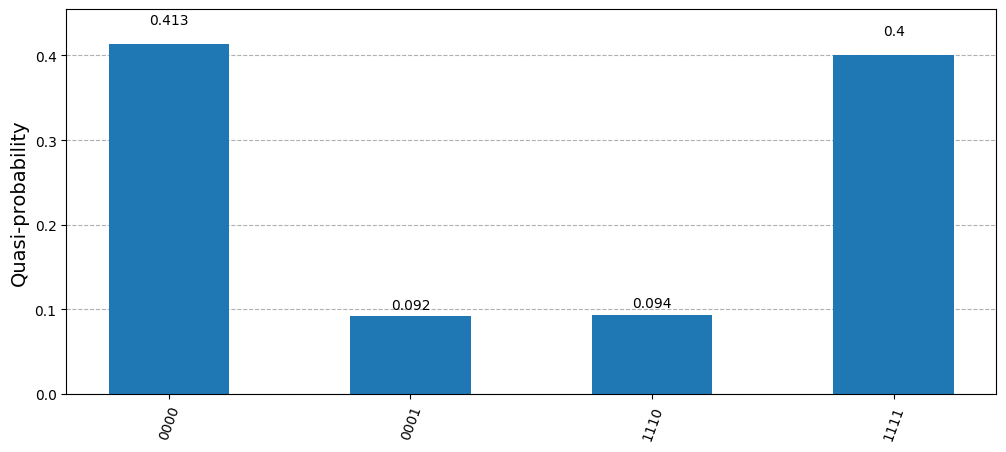

In [54]:
noise_bit_flip = bitflip_model(0.03)
simulator = qiskit_aer.AerSimulator()
transpiled_qc = qiskit.transpile(qc, simulator, basis_gates=noise_bit_flip.basis_gates)

shots = 10_000
job = simulator.run(transpiled_qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

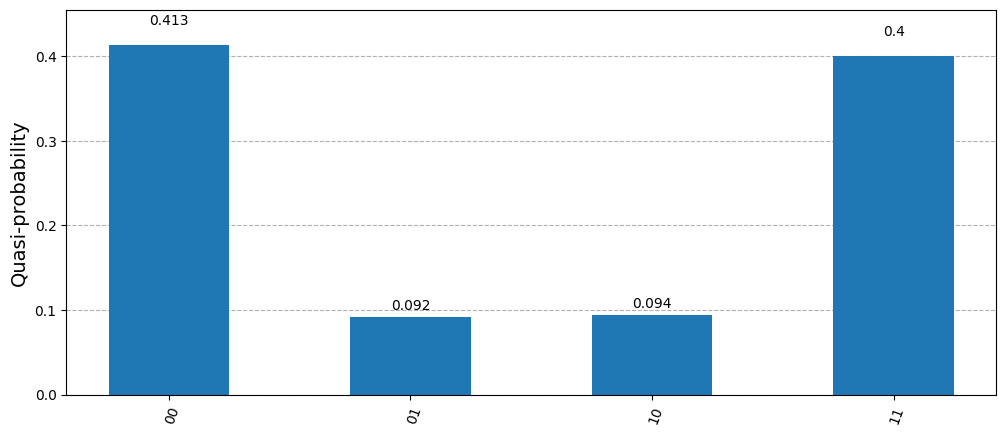

In [55]:
results = {setting: probabilities}
dec_res = decode_results(results, charlie_size)
probs = dec_res[setting]
plot_distribution(probs, figsize=(12, 5))

## Experiment

Run EWFS experiment for a specific number of shots, trials, and over a range of friend sizes.

#### Run experiment

In [81]:
all_experiment_combos = [
    [PEEK, REVERSE_1],
    [PEEK, REVERSE_2],
    [REVERSE_2, REVERSE_1],
    [REVERSE_2, REVERSE_2],
]

# The tasks dictionary has a key that corresponds to the qubit
# system size with an associated value of the task for that size.
tasks = defaultdict(dict)

# Construct all circuits to be run over all qubit sizes.
for charlie_size in friend_sizes:
    for trial in range(1, num_trials + 1):
        circuits = {}
    
        # Create circuits for each EWFS setting.
        # Note, we remove barriers in the Qiskit circuit.
        for alice, bob in all_experiment_combos:
            circuits[(alice, bob)] = RemoveBarriers()(
                ewfs(alice, bob, strategy, ANGLES, BETA, charlie_size, 1)
            )
    
        # Use backend to transpile circuits.
        transpiled_circuits = {
            k:  qiskit.transpile(circuit, backend, optimization_level=0)
            for k, circuit in circuits.items()
        }
    
        # Run task.
        print(f"Trial {trial} out of {num_trials} for task of {charlie_size=}")
        tasks[trial][charlie_size] = backend.run(
            list(transpiled_circuits.values()),
            shots=shots,
            verbatim=True,
        )
        print(f"Task with task ID: {tasks[trial][charlie_size].job_id()}\n")

Trial 1 out of 2 for task of charlie_size=1
Task with task ID: 7ef5defd-2b90-4eed-908e-d4271f8e8060

Trial 2 out of 2 for task of charlie_size=1
Task with task ID: 818b1848-9631-4451-8520-d9b2229f26f1

Trial 1 out of 2 for task of charlie_size=2
Task with task ID: ffcd70af-e4be-4038-b1c1-2d86c62ca035

Trial 2 out of 2 for task of charlie_size=2
Task with task ID: 0d9832ec-9dd5-4524-b2de-12f8c7a985d5



#### Post-processing

In [85]:
results = {}
post_processed_results = {
    fs: {inequality: [] for inequality in ["semi_brukner"]}
    for fs in friend_sizes
}
for trial in tasks:
    for charlie_size, task in tasks[trial].items():
        print(f"Processing trial {trial} for task with task ID: {task.job_id()}")

        result = task.result()
        for key, count in zip(transpiled_circuits.keys(), result.get_counts()):
            probabilities = {k[::-1]: v / shots for k, v in count.items()}
            results[key] = probabilities
        print(f"Results: {results}")
    
        # Compute violations from result counts.
        violations = compute_violations(
            results=results,
            charlie_size=charlie_size,
            debbie_size=1,
            strategy=strategy,
            verbose=True
        )
        print(f"Violations: {violations}\n")
    
        for key in violations:
            post_processed_results[charlie_size][key].append(violations[key])
    
        # Save data after each trial of each charlie_size.
        if save:
            save_data(results=results,
                      friend_size=charlie_size,
                      trial=trial,
                      shots=shots,
                      data_path=new_dir_path,
                      backend_name=backend_name)

Processing trial 1 for task with task ID: 7ef5defd-2b90-4eed-908e-d4271f8e8060
Results: {(1, 2): {'00': 0.0925, '11': 0.0895, '01': 0.415, '10': 0.403}, (1, 3): {'10': 0.0907, '01': 0.0875, '11': 0.411, '00': 0.4108}, (3, 2): {'10': 0.4457, '11': 0.0545, '00': 0.0602, '01': 0.4396}, (3, 3): {'11': 0.0585, '00': 0.0592, '01': 0.4333, '10': 0.449}}
semi_brukner=0.8148 -- is violated: True
Violations: {'semi_brukner': 0.8148}

Writing data to: ../data/majority_vote_aer_simulator_20240818-093746/aer_simulator_qubits_1_trial_1_shots_10000.pickle
Processing trial 1 for task with task ID: ffcd70af-e4be-4038-b1c1-2d86c62ca035
Results: {(1, 2): {'111': 0.085, '001': 0.4102, '000': 0.0886, '110': 0.4162}, (1, 3): {'001': 0.0916, '111': 0.4087, '110': 0.0881, '000': 0.4116}, (3, 2): {'11': 0.0588, '01': 0.4386, '00': 0.0603, '10': 0.4423}, (3, 3): {'10': 0.438, '01': 0.4432, '00': 0.0608, '11': 0.058}}
semi_brukner=0.8176000000000001 -- is violated: True
Violations: {'semi_brukner': 0.81760000000